# Day 7 — Retrain with Best Params + OOF Predictions
**Real Estate Fraud Detection**

Goal: Retrain LightGBM with Optuna best params, get new OOF predictions, compare vs baseline.

**Prerequisites:** Day 6 completed → `configs/best_params.yaml` exists

## 0. Set Project Root

In [1]:
import os
from pathlib import Path

project_root = Path.cwd()
while not (project_root / 'configs').exists():
    project_root = project_root.parent
os.chdir(project_root)
print(f'Working directory: {os.getcwd()}')

Working directory: C:\Users\mehal\Downloads\machinelearning\real_estate_fraud_detection


## 1. Imports & Config

In [2]:
import os, sys
sys.path.insert(0, os.path.abspath('.'))

import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='mlflow')
os.environ['GIT_PYTHON_REFRESH'] = 'quiet'

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.ingestion import load_config
from src.models import setup_mlflow, retrain_best_model, save_model
from src.evaluate import (
    pr_auc_score, recall_at_precision,
    plot_all_pr_curves, plot_threshold_analysis,
)

CONFIG_PATH = 'configs/config.yaml'
PLOTS_DIR   = 'reports/plots'
cfg = load_config(CONFIG_PATH)
setup_mlflow(cfg)
Path(PLOTS_DIR).mkdir(parents=True, exist_ok=True)
print(f'Config: {cfg["project"]["name"]} v{cfg["project"]["version"]}')

2026-05-17 15:42:08,712 - src.ingestion - INFO - Config loaded from configs\config.yaml — project: real_estate_fraud_detection v1.1.0
2026-05-17 15:42:08,745 - src.models - INFO - MLflow: tracking_uri=logs/mlruns | experiment=real-estate-fraud-v1


Config: real_estate_fraud_detection v1.1.0


## 2. Load Splits + Best Params

In [3]:
splits_path = Path(cfg['data']['splits_path'])
X_train = pd.read_parquet(splits_path / 'X_train.parquet')
y_train = pd.read_parquet(splits_path / 'y_train.parquet').squeeze()
print(f'X_train: {X_train.shape} | fraud: {y_train.mean()*100:.2f}%')

# Load best params from Day 6
best_params_path = Path('configs/best_params.yaml')
if not best_params_path.exists():
    raise FileNotFoundError('configs/best_params.yaml not found — run Day 6 first!')

best_params = yaml.safe_load(open(best_params_path))['lgbm_best_params']
print(f'\nBest params loaded from {best_params_path}:')
for k, v in best_params.items():
    print(f'  {k:<25}: {v}')

X_train: (240000, 24) | fraud: 7.82%

Best params loaded from configs\best_params.yaml:
  colsample_bytree         : 0.7878169701860978
  learning_rate            : 0.07543753502638627
  max_depth                : 5
  min_child_samples        : 22
  n_estimators             : 306
  n_jobs                   : -1
  num_leaves               : 42
  random_state             : 42
  reg_alpha                : 5.045065527723589e-07
  reg_lambda               : 1.0039320517727244e-05
  scale_pos_weight         : 11.78
  subsample                : 0.8359541264922199
  verbose                  : -1


## 3. Load Baseline OOF for Comparison

In [4]:
oof_path     = Path(cfg['data']['processed_path']) / 'oof_predictions.parquet'
oof_baseline = pd.read_parquet(oof_path)

baseline_pr  = pr_auc_score(oof_baseline['y_true'].values, oof_baseline['oof_lgbm'].values)
baseline_rec = recall_at_precision(oof_baseline['y_true'].values, oof_baseline['oof_lgbm'].values)

print(f'Baseline LGBM OOF PR-AUC   : {baseline_pr:.4f}')
print(f'Baseline LGBM Recall@95P   : {baseline_rec:.4f}')
print(f'\n→ Tuned model must beat PR-AUC > {baseline_pr:.4f}')

Baseline LGBM OOF PR-AUC   : 0.7701
Baseline LGBM Recall@95P   : 0.0680

→ Tuned model must beat PR-AUC > 0.7701


## 4. Retrain with Best Params

> Full GroupKFold(5) CV — same structure as Day 5 baseline but with tuned params.

In [5]:
print('Retraining LightGBM with best Optuna params...')
tuned_results = retrain_best_model(X_train, y_train, cfg, best_params)

print(f'\n✅ Tuned LGBM Results:')
print(f'  PR-AUC Mean  : {tuned_results["mean_pr_auc"]:.4f} ± {tuned_results["std_pr_auc"]:.4f}')
print(f'  Recall@95P   : {tuned_results["mean_recall"]:.4f}')
print(f'  OOF PR-AUC   : {tuned_results["oof_pr_auc"]:.4f}')

improvement_pr  = tuned_results['mean_pr_auc'] - baseline_pr
improvement_rec = tuned_results['mean_recall'] - baseline_rec
print(f'\n  vs Baseline:')
print(f'  PR-AUC  : {improvement_pr:+.4f} {"✅" if improvement_pr > 0 else "⚠️"}')
print(f'  Recall  : {improvement_rec:+.4f} {"✅" if improvement_rec > 0 else "⚠️"}')

Retraining LightGBM with best Optuna params...


2026-05-17 15:42:14,503 - src.models - INFO - Day 7 — Retraining with best Optuna params
2026-05-17 15:42:17,043 - src.features - INFO - FeatureEngineer.fit() — computing fold-dependent stats
2026-05-17 15:42:17,628 - src.features - INFO -   Cities: 1422 | States: 54 | Zip codes: 18425
2026-05-17 15:42:17,862 - src.features - INFO - Fold-dependent features added — 24 total cols
2026-05-17 15:42:17,937 - src.features - INFO - Fold-dependent features added — 24 total cols
2026-05-17 15:42:18,231 - src.features - INFO - Stateless features added — 9 new columns
2026-05-17 15:42:18,314 - src.features - INFO - Stateless features added — 9 new columns
2026-05-17 15:42:18,319 - src.preprocessing - INFO - Preprocessor built — 19 numerical, 2 categorical
C:\Users\mehal\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026-05-17 15:42:26,290 - src.mod


✅ Tuned LGBM Results:
  PR-AUC Mean  : 0.7839 ± 0.0360
  Recall@95P   : 0.1105
  OOF PR-AUC   : 0.7779

  vs Baseline:
  PR-AUC  : +0.0138 ✅
  Recall  : +0.0425 ✅


## 5. Full Comparison Table

In [6]:
comparison = pd.DataFrame([
    {
        'Model':       'LR Baseline',
        'PR-AUC':      round(pr_auc_score(oof_baseline['y_true'].values, oof_baseline['oof_lr'].values), 4),
        'Recall@95P':  round(recall_at_precision(oof_baseline['y_true'].values, oof_baseline['oof_lr'].values), 4),
        'Stage':       'Baseline',
    },
    {
        'Model':       'LGBM Baseline',
        'PR-AUC':      round(baseline_pr, 4),
        'Recall@95P':  round(baseline_rec, 4),
        'Stage':       'Baseline',
    },
    {
        'Model':       'LGBM Tuned',
        'PR-AUC':      round(tuned_results['oof_pr_auc'], 4),
        'Recall@95P':  round(tuned_results['mean_recall'], 4),
        'Stage':       'Tuned ← Day 7',
    },
])

print('=== MODEL COMPARISON ===')
print(comparison.to_string(index=False))

=== MODEL COMPARISON ===
        Model  PR-AUC  Recall@95P         Stage
  LR Baseline  0.5952      0.0000      Baseline
LGBM Baseline  0.7701      0.0680      Baseline
   LGBM Tuned  0.7779      0.1105 Tuned ← Day 7


## 6. PR Curve Comparison

2026-05-17 15:43:01,475 - src.evaluate - INFO - PR curves saved → reports/plots/pr_curves_comparison.png


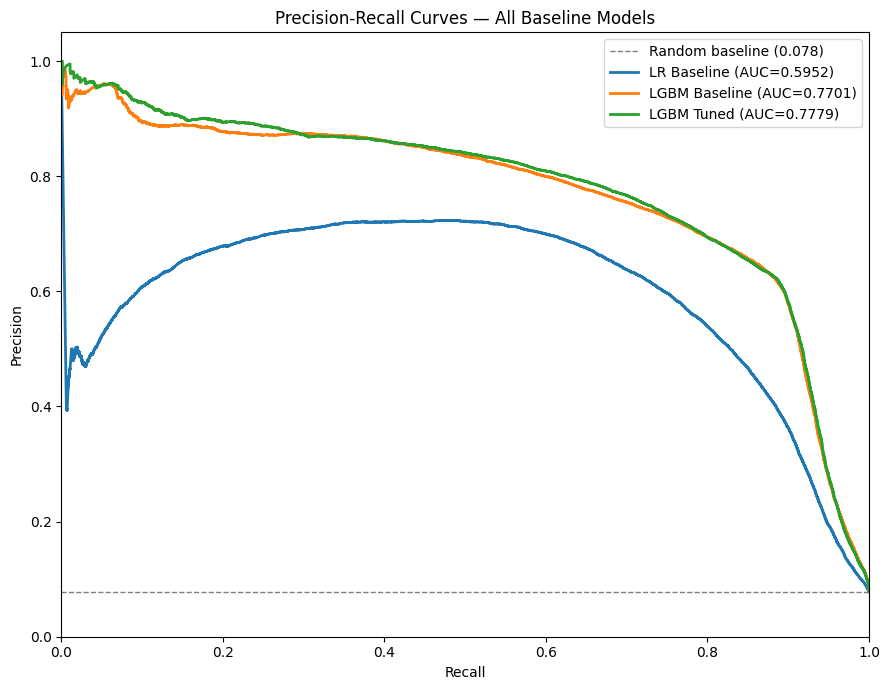

In [7]:
plot_all_pr_curves(
    results={
        'LR Baseline':    oof_baseline['oof_lr'].values,
        'LGBM Baseline':  oof_baseline['oof_lgbm'].values,
        'LGBM Tuned':     tuned_results['oof_probs'],
    },
    y_true=oof_baseline['y_true'].values,
    plots_dir=PLOTS_DIR,
    show=True,
)

## 7. Per-Fold Variance — Tuned vs Baseline

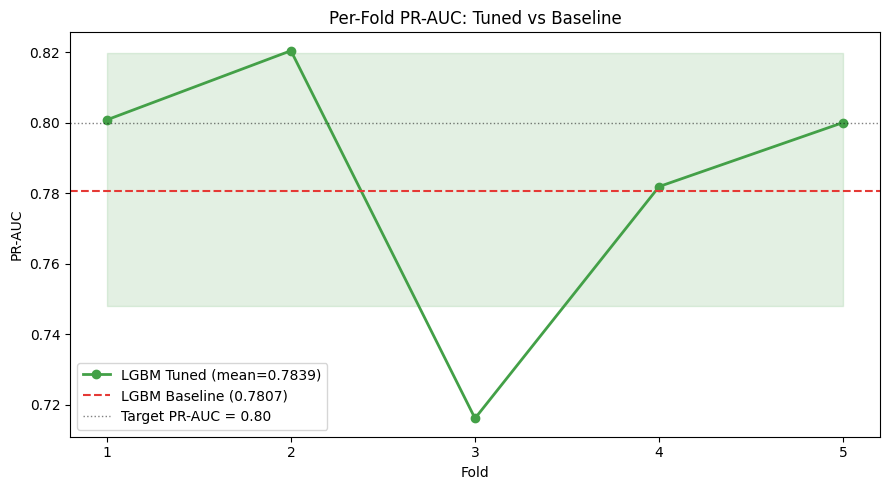


Fold stability:
  Tuned  std = 0.0360 ✅


In [8]:
baseline_report = pd.read_csv(Path(cfg['paths']['reports']) / 'baseline_report.csv')
lgbm_row = baseline_report[baseline_report['Model'] == 'LightGBM (tabular)'].iloc[0]

fig, ax = plt.subplots(figsize=(9, 5))

n_folds = len(tuned_results['fold_metrics'])
folds   = list(range(1, n_folds + 1))
tuned_pr = [m['pr_auc'] for m in tuned_results['fold_metrics']]

ax.plot(folds, tuned_pr, 'o-', color='#43A047', lw=2, label=f'LGBM Tuned (mean={tuned_results["mean_pr_auc"]:.4f})')
ax.axhline(lgbm_row['PR-AUC Mean'], color='#E53935', ls='--', lw=1.5,
           label=f'LGBM Baseline ({lgbm_row["PR-AUC Mean"]:.4f})')
ax.axhline(0.80, color='black', ls=':', lw=1, alpha=0.5, label='Target PR-AUC = 0.80')
ax.fill_between(folds,
                tuned_results['mean_pr_auc'] - tuned_results['std_pr_auc'],
                tuned_results['mean_pr_auc'] + tuned_results['std_pr_auc'],
                alpha=0.15, color='#43A047')
ax.set_xlabel('Fold')
ax.set_ylabel('PR-AUC')
ax.set_title('Per-Fold PR-AUC: Tuned vs Baseline')
ax.legend()
ax.set_xticks(folds)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/tuned_vs_baseline_folds.png', dpi=150)
plt.show()

print(f'\nFold stability:')
print(f'  Tuned  std = {tuned_results["std_pr_auc"]:.4f} {"✅" if tuned_results["std_pr_auc"] < 0.05 else "⚠️ high variance"}')

## 8. Threshold Analysis — Tuned Model

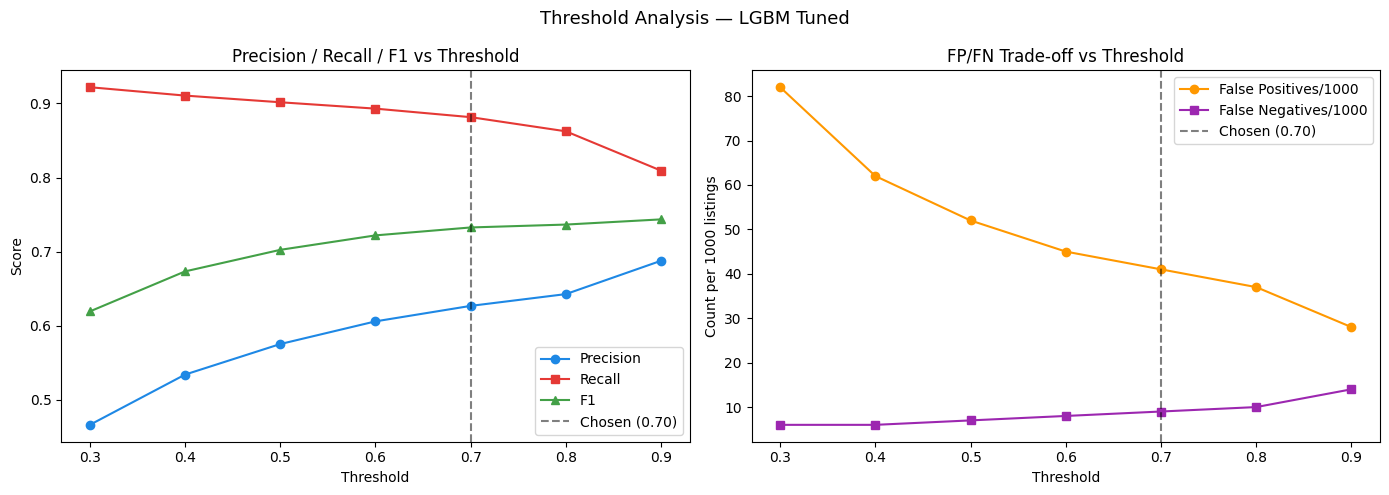


Threshold sensitivity — LGBM Tuned:
 Threshold  Precision  Recall     F1  FP/1000  FN/1000
       0.3     0.4664  0.9219 0.6194       82        6
       0.4     0.5342  0.9106 0.6734       62        6
       0.5     0.5754  0.9016 0.7025       52        7
       0.6     0.6060  0.8930 0.7220       45        8
       0.7     0.6269  0.8815 0.7327       41        9
       0.8     0.6428  0.8624 0.7366       37       10
       0.9     0.6878  0.8093 0.7436       28       14


In [9]:
thresh_df = plot_threshold_analysis(
    oof_baseline['y_true'].values,
    tuned_results['oof_probs'],
    'LGBM Tuned',
    plots_dir=PLOTS_DIR,
    show=True,
)
print('\nThreshold sensitivity — LGBM Tuned:')
print(thresh_df.to_string(index=False))

## 9. Save Tuned OOF Predictions + Model Artifact

In [10]:
# Update OOF file with tuned predictions
oof_updated = oof_baseline.copy()
oof_updated['oof_lgbm_tuned'] = tuned_results['oof_probs']
oof_updated.to_parquet(oof_path, index=False)
print(f'✅ OOF predictions updated → {oof_path}')
print(f'   Columns: {list(oof_updated.columns)}')

# Save tuned model params for Day 8 stacking
tuned_params_path = Path(cfg['data']['processed_path']) / 'tuned_results.pkl'
import pickle
with open(tuned_params_path, 'wb') as f:
    pickle.dump({
        'best_params':    best_params,
        'tuned_results':  tuned_results,
        'oof_pr_auc':     tuned_results['oof_pr_auc'],
    }, f)
print(f'✅ Tuned results saved → {tuned_params_path}')

✅ OOF predictions updated → data\processed\oof_predictions.parquet
   Columns: ['y_true', 'oof_lr', 'oof_lgbm', 'oof_lgbm_text', 'oof_lgbm_tuned']
✅ Tuned results saved → data\processed\tuned_results.pkl


## 10. Day 7 Exit Criteria

In [11]:
pr_target  = 0.80
rec_target = 0.40

print('=== DAY 7 EXIT CRITERIA ===')
checks = [
    ('best_params.yaml loaded correctly',
     bool(best_params)),
    ('Tuned model PR-AUC > baseline',
     tuned_results['mean_pr_auc'] > baseline_pr),
    (f'PR-AUC > {pr_target} target',
     tuned_results['mean_pr_auc'] > pr_target),
    (f'Recall@95P > {rec_target} target',
     tuned_results['mean_recall'] > rec_target),
    ('MLflow tuned run logged',
     bool(tuned_results['run_id'])),
    ('OOF predictions updated',
     'oof_lgbm_tuned' in oof_updated.columns),
    ('Low fold variance (std < 0.05)',
     tuned_results['std_pr_auc'] < 0.05),
]

all_pass = True
for label, result in checks:
    icon = '☑' if result else '☒'
    if not result:
        all_pass = False
    print(f'  {icon} {label}')

print(f'\n{"✅ All checks passed" if all_pass else "⚠️ Some checks failed"}')

print(f'\n=== FINAL NUMBERS (Day 7) ===')
print(f'| Model         | PR-AUC | Recall@95P |')
print(f'|---------------|--------|------------|')
print(f'| LR Baseline   | {pr_auc_score(oof_baseline["y_true"].values, oof_baseline["oof_lr"].values):.4f} | {recall_at_precision(oof_baseline["y_true"].values, oof_baseline["oof_lr"].values):.4f}     |')
print(f'| LGBM Baseline | {baseline_pr:.4f} | {baseline_rec:.4f}     |')
print(f'| LGBM Tuned    | {tuned_results["oof_pr_auc"]:.4f} | {tuned_results["mean_recall"]:.4f}     |')

print(f'\n→ Ready for Day 8 — Stacking Ensemble + Calibration')

=== DAY 7 EXIT CRITERIA ===
  ☑ best_params.yaml loaded correctly
  ☑ Tuned model PR-AUC > baseline
  ☒ PR-AUC > 0.8 target
  ☒ Recall@95P > 0.4 target
  ☑ MLflow tuned run logged
  ☑ OOF predictions updated
  ☑ Low fold variance (std < 0.05)

⚠️ Some checks failed

=== FINAL NUMBERS (Day 7) ===
| Model         | PR-AUC | Recall@95P |
|---------------|--------|------------|
| LR Baseline   | 0.5952 | 0.0000     |
| LGBM Baseline | 0.7701 | 0.0680     |
| LGBM Tuned    | 0.7779 | 0.1105     |

→ Ready for Day 8 — Stacking Ensemble + Calibration
